In [49]:
#!pip install matplotlib

In [84]:
import numpy as np
import time
import torch
import time
import sys
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


In [85]:
# Generate Networks
import numpy as np
import networkx as nx
from scipy.stats import nbinom
import matplotlib.pyplot as plt
import secrets

## Kuramoto Model

In [108]:
import torch
import numpy as np
from typing import List
import tqdm

#Complex = torch.complex128

class KuramotoFast:
    def __init__(self, n_nodes: int, n_oscillators: int, sampling_rate: int, k_list: List[float], weight_matrix: np.ndarray,
                 frequency_spread: float, noise_scale: float=1.0, use_cuda: bool=True, use_tqdm: bool=True, node_frequencies=None, **kwargs):
        """
            Implementation of nested Kuramoto model using PyTorch. The model consists of N nodes each with M oscillators. Each pair of nodes is connected with directed weight given by weight_matrix.

            :param n_nodes: number of nodes in the model
            :param n_oscillators: number of oscillators in each node
            :param sampling_rate: update rate of the model
            :param k_list: list of K values (within node shift) of the model. Should have length equal to number of nodes.
            :param weight_matrix: 2d matrix of node vs node connectivity weight. Should have N_nodes x N_nodes shape.
            :param frequency_spread: spread of frequencies within a node. Frequencies of oscillators are defined as linspace from central_frequency - frequency_spread to central_frequency + frequency_spread
            :param noise_scale: sigma of noise.
            :param use_cuda: use GPU (PyTorch CUDA/ROCm) to compute the model?
        """
        self._check_parameters(n_nodes, k_list, weight_matrix)

        # Set device
        if use_cuda and torch.cuda.is_available():
            self.device = torch.device("cuda")
            device_name = "GPU (CUDA/ROCm)"
        else:
            self.device = torch.device("cpu")
            device_name = "CPU"
        print(f"Using device: {device_name}")

        self.n_nodes = n_nodes
        self.n_oscillators = n_oscillators
        self.k_list = k_list
        self.noise_scale = 2 * np.pi * noise_scale / sampling_rate

        self.frequency_spread = frequency_spread
        self.node_frequencies = node_frequencies

        # Convert weight_matrix to PyTorch tensor
        self.weight_matrix = torch.tensor(weight_matrix, dtype=torch.float32, device=self.device)
        torch.diagonal(self.weight_matrix).fill_(0)  # Set diagonal to 0
        self.weight_matrix = self.weight_matrix.T  # Transpose for directed connectivity

        self.sampling_rate = sampling_rate
        self.dt = 1.0 / sampling_rate
        self.use_cuda = use_cuda
        self.disable_tqdm = not(use_tqdm)

        self._init_parameters()
        self._preallocate()

    def _check_parameters(self, n_nodes: int, k_list: List[float], weight_matrix: np.ndarray):
        if len(k_list) != n_nodes:
            raise RuntimeError(f'Size of k_list ({len(k_list)}) is not equal to number of nodes ({n_nodes}).')
        if np.ndim(weight_matrix) != 2 or (weight_matrix.shape[0] != weight_matrix.shape[1]):
            raise RuntimeError(f'weight_matrix should be a 2d square matrix, got {weight_matrix.shape} shape.')
        if weight_matrix.shape[0] != n_nodes or weight_matrix.shape[1] != n_nodes:
            raise RuntimeError(f'weight matrix should be a 2d matrix of size N_nodes x N_nodes, got {weight_matrix.shape} shape')

    def _init_parameters(self):
        # Angular frequencies in rad/s
        omegas = torch.zeros((self.n_nodes, self.n_oscillators), dtype=torch.float32, device=self.device)
        for idx, frequency in enumerate(self.node_frequencies):
            freq_lower = frequency - self.frequency_spread
            freq_upper = frequency + self.frequency_spread
            omegas[idx] = torch.linspace(freq_lower, freq_upper, steps=self.n_oscillators, device=self.device, dtype=torch.float32)

        omegas += torch.rand(omegas.shape, device=self.device, dtype=torch.float32) * 0.2 - 0.1  # Uniform [-0.1, 0.1]
        self.omegas = omegas * 2 * np.pi  # rad/s

        # Shift coeffs
        C = torch.tensor(self.k_list, dtype=torch.float32, device=self.device) / self.n_oscillators
        self.shift_coeffs = C.view(-1, 1)

        # Random initial phase
        thetas = torch.rand(omegas.shape, device=self.device, dtype=torch.float32) * 2 * np.pi - np.pi  # Uniform [-π, π]
        self.phases = torch.exp(1j * thetas).to(torch.complex64)

        self._complex_dtype = torch.complex64
        self._float_dtype = torch.float32

    def _preallocate(self):
        n_nodes, n_osc = self.phases.shape
        self._phase_conj = torch.empty_like(self.phases)
        self._external_buffer = torch.empty((n_nodes, n_nodes, n_osc), dtype=self.phases.dtype, device=self.device)

    def _compute_rhs(self, phases):
        mean_phase = torch.mean(phases, dim=1)  # Shape: (n_nodes,)
        self._phase_conj = torch.conj(phases)  # Shape: (n_nodes, n_oscillators)

        # External dynamics
        # tensordot computes outer product: (n_nodes, n_oscillators) × (n_nodes,) → (n_nodes, n_oscillators, n_nodes)
        # permute reorders to (n_nodes, n_nodes, n_oscillators)
        self._external_buffer = torch.tensordot(self._phase_conj, mean_phase, dims=0).permute(0, 2, 1)
        weight_expanded = self.weight_matrix[:, :, None].expand(-1, -1, self.n_oscillators)  # Shape: (n_nodes, n_nodes, n_oscillators)
        self._external_buffer *= weight_expanded
        external = self._external_buffer.sum(dim=1)  # Shape: (n_nodes, n_oscillators)
        external_rhs = external.imag / self.n_nodes

        # Internal dynamics
        self._phase_conj = phases * torch.sum(self._phase_conj, dim=1, keepdim=True)
        self._phase_conj = torch.conj(self._phase_conj)
        internal_rhs = self._phase_conj.imag * self.shift_coeffs

        rhs = self.omegas + internal_rhs + external_rhs
        return rhs
    
    def _rotate(self, dtheta):
        """exp(i * dtheta) as complex64."""
        return torch.polar(torch.ones_like(dtheta), dtheta)

    def simulate(self, time: float, noise_realisations: int=100, random_seed: int=42) -> np.ndarray:
        torch.manual_seed(random_seed)
        n_iters = int(time * self.sampling_rate)
        history = torch.zeros((self.n_nodes, n_iters + 1), dtype=self._complex_dtype, device=self.device)
        history[:, 0] = self.phases.mean(dim=1)
        for i in tqdm.trange(1, n_iters + 1, leave=False, desc='Kuramoto model is running...', disable=self.disable_tqdm):
            # RK4 steps
            k1 = self._compute_rhs(self.phases)
            phases2 = self.phases * self._rotate((self.dt / 2) * k1)
            k2 = self._compute_rhs(phases2)
            phases3 = self.phases * self._rotate((self.dt / 2) * k2)
            k3 = self._compute_rhs(phases3)
            phases4 = self.phases * self._rotate(self.dt * k3)
            k4 = self._compute_rhs(phases4)
            rhs = (k1 + 2 * k2 + 2 * k3 + k4) / 6
            shift_noise = torch.normal(
                mean=0.0, std=self.noise_scale, size=rhs.shape,
                device=self.device, dtype=torch.float32,
            )
            rhs += shift_noise
            self.phases = self.phases * self._rotate(self.dt * rhs)
            history[:, i] = self.phases.mean(dim=1)
        history = history.cpu().numpy()
        return history

# Some other functions

In [94]:
from numpy.polynomial.polynomial import polyfit, polyval

def FA_metric(phasor, scales):
    """ y: cummulative sum, and scales should be defined"""
    y = calc_detrened(phasor)
    F_fa = np.zeros(len(scales))
    
    for i, s in enumerate(scales):

        diffs = y[s:] - y[:-s]
        F_fa[i] = np.sqrt(np.mean(diffs**2))

    # Fit log–log slope
    coeff_fa = np.polyfit(np.log2(scales), np.log2(F_fa), 1)
    alpha_fa = coeff_fa[0]
    fit_fa = 2 ** np.polyval(coeff_fa, np.log2(scales))

    # plt.figure(figsize=(7, 5))
    # plt.loglog(scales, F_fa, 'o', label="FA Data")
    # plt.loglog(scales, fit_fa, 'r--', label=f"Fit: α = {alpha_fa:.2f}")
    # plt.title("Fluctuation Analysis (FA)")
    # plt.xlabel("log₂(Window size s)")
    # plt.ylabel("log₂(Fluctuation F(s))")
    # plt.legend()
    # plt.grid(True, which="both", ls="--")
    # plt.show()

    print(f"Estimated FA exponent α = {alpha_fa:.3f}")

    return fit_fa, alpha_fa

def calc_detrened(data):
    x = np.abs(data)
    y = np.cumsum(x - np.mean(x))

    return y

def dfa_rms(y, scale):
    n_windows = len(y) // scale

    if n_windows == 0:
        return np.nan  # scale too large
        
    shape = (n_windows, scale)
    Y = np.lib.stride_tricks.as_strided(y, shape=shape)
    rms = np.zeros(n_windows)
    scale_axis = np.arange(scale)

    for i, window in enumerate(Y):
        coeff = np.polyfit(scale_axis, window, 1)
        trend = np.polyval(coeff, scale_axis)
        rms[i] = np.sqrt(np.mean((window - trend) ** 2))
    return np.mean(rms)


def dfa_scales(min_exp=5, max_exp=9, step=0.25):
    """
    Logarithmic scales: 2^5 ... 2^9 in reasonable increments.
    Ensures scales are strictly increasing and unique.
    """
    scales = np.round(2 ** np.arange(min_exp, max_exp, step)).astype(int)
    scales = np.unique(scales)
    return scales

def DFA(data):
    """
    Full DFA1 for a complex phasor time series.
    Returns (alpha, scales, F)
    """
    y = calc_detrened(data)
    scales = dfa_scales()

    F = []
    for s in scales:
        rms_val = dfa_rms(y, s)
        if not np.isnan(rms_val):
            F.append(rms_val)
        else:
            F.append(np.nan)

    F = np.array(F)

    # Remove invalid scales
    mask = ~np.isnan(F)
    scales = scales[mask]
    F = F[mask]

    coeff = np.polyfit(np.log2(scales), np.log2(F), 1)
    alpha = coeff[0]

    return alpha, scales, F


In [95]:
def plv_func(x, y):
    x_f = x / np.abs(x)
    y_f = y / np.abs(y)
    plv_values = 1/len(x_f) * np.dot(x_f, np.conj(y_f))
    return np.abs(plv_values)

# New function
def plv_matrix_vectorized(inst_theta):
    X = np.exp(1j * inst_theta)          # (T, N)
    M = np.dot(X.conj().T, X) / X.shape[0]
    return np.abs(M)

In [96]:
## START
# Load the compressed .npz file
data = np.load("adjacency_matrices.npz")
# Access the matrices using the key used during saving
all_adj = data["adjacency_matrices"]

In [97]:
all_adj.shape

(11, 3, 1000, 1000)

0 0 LL


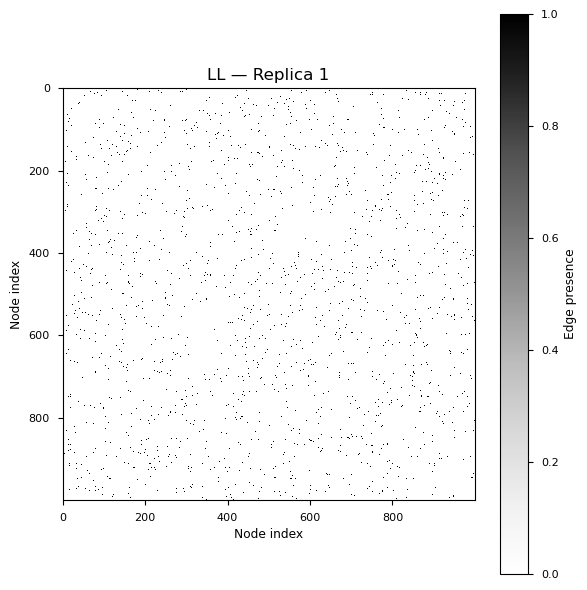

0 1 LL


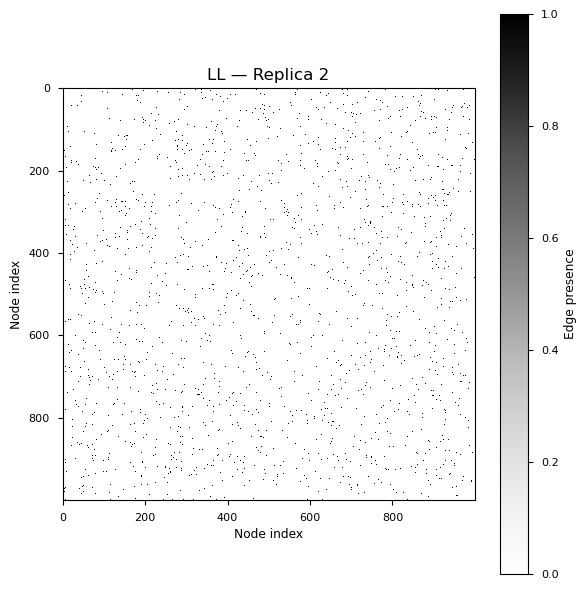

0 2 LL


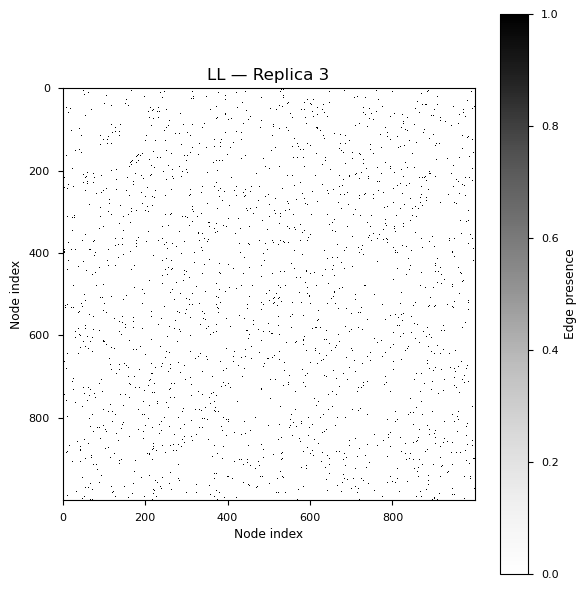

1 0 LH


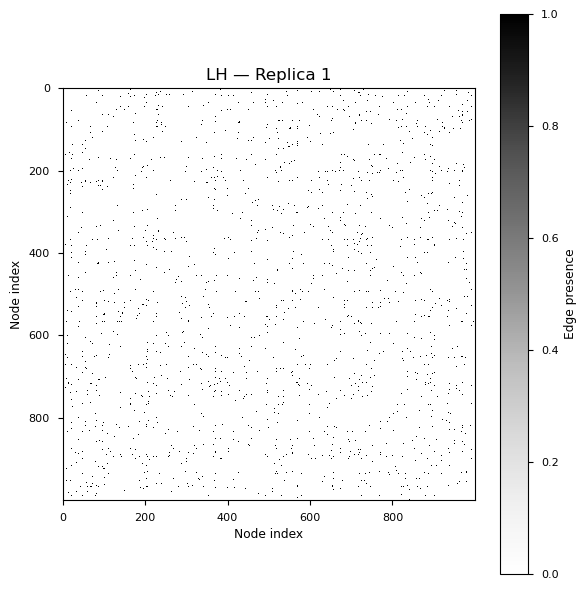

1 1 LH


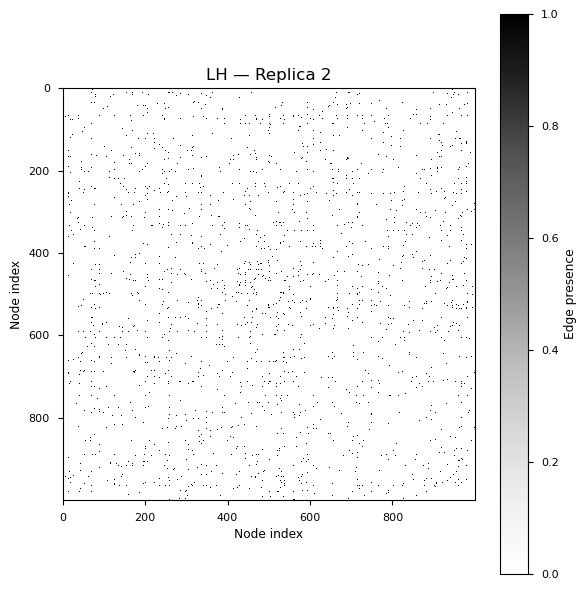

1 2 LH


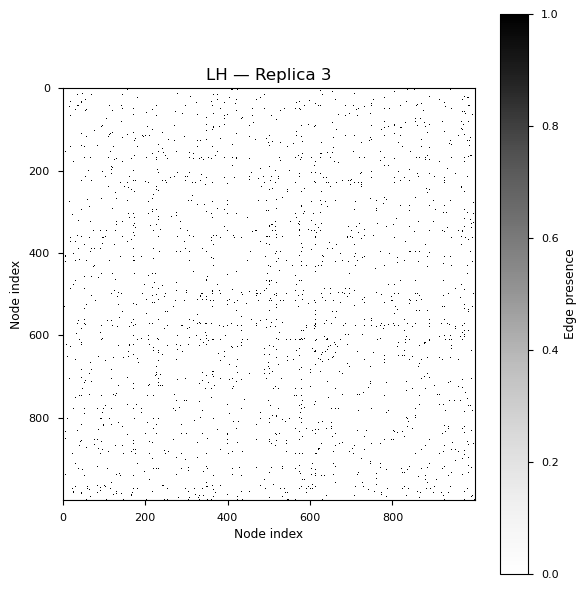

2 0 HL


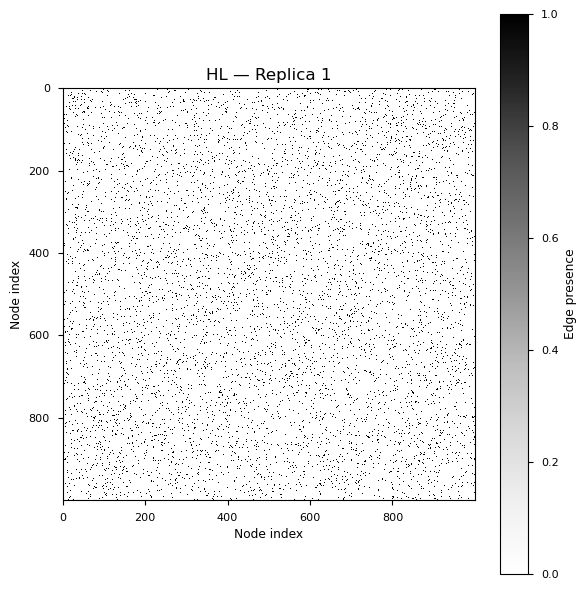

2 1 HL


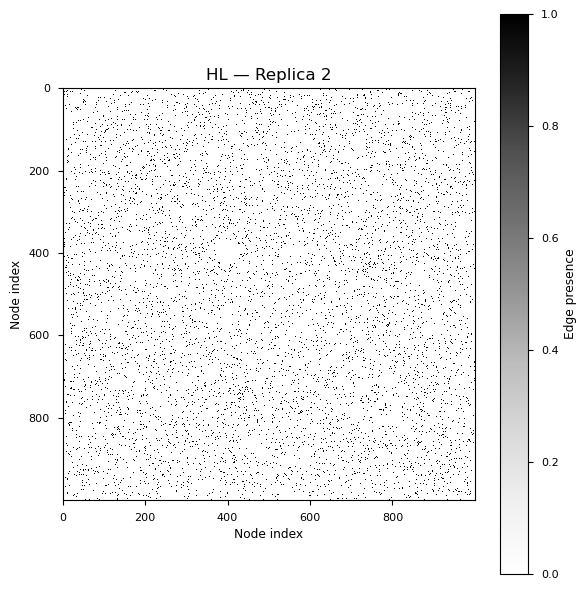

2 2 HL


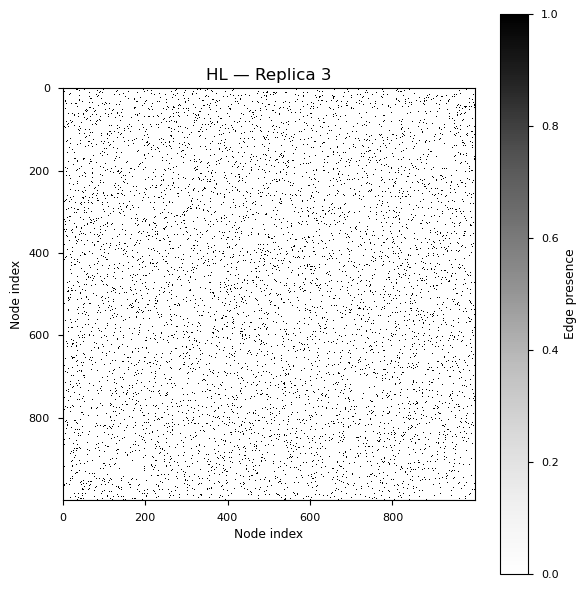

3 0 HH


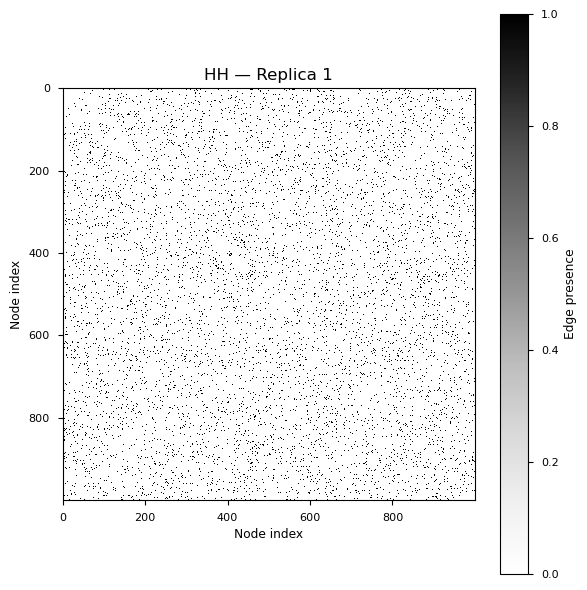

3 1 HH


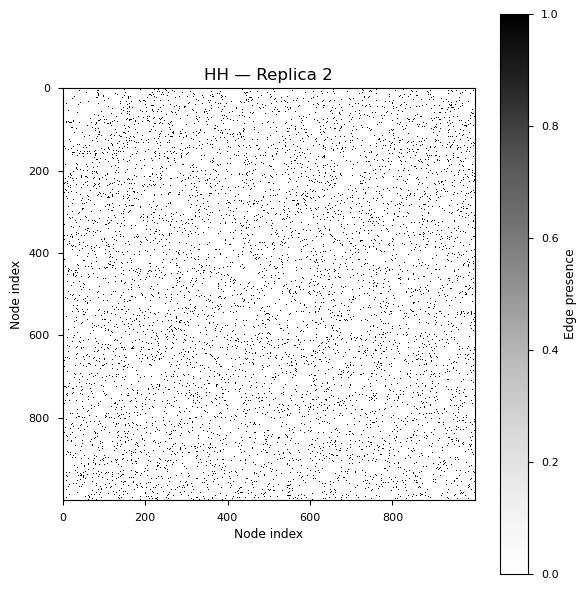

3 2 HH


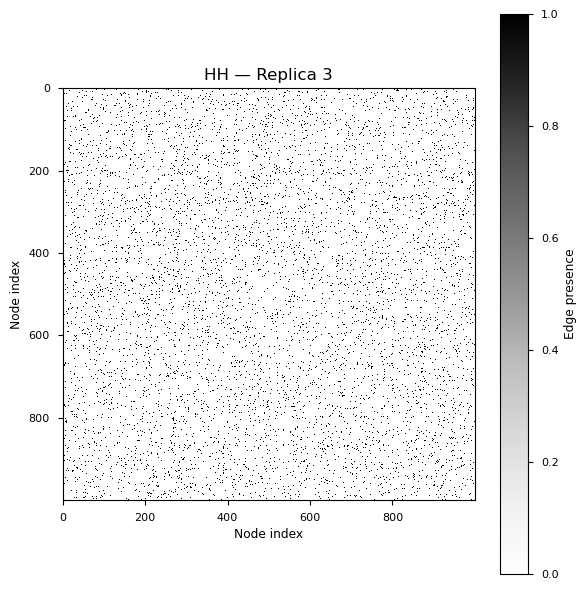

4 0 Watts–Strogatz Low mean


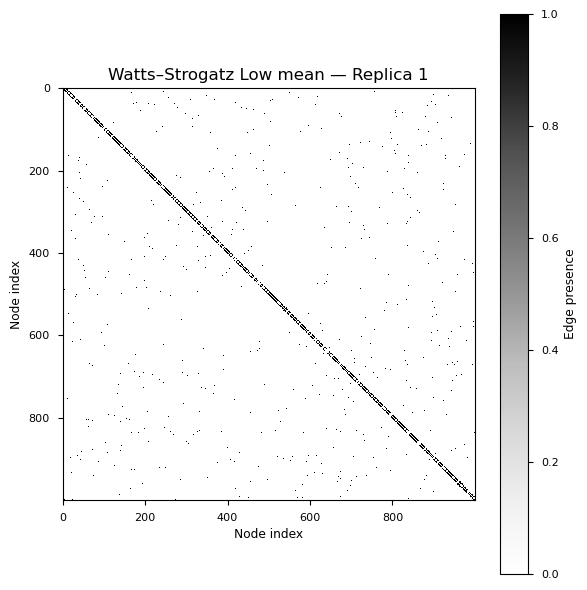

4 1 Watts–Strogatz Low mean


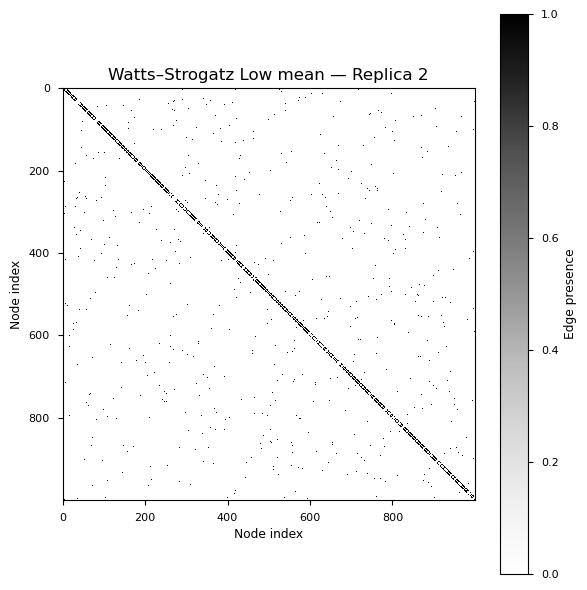

4 2 Watts–Strogatz Low mean


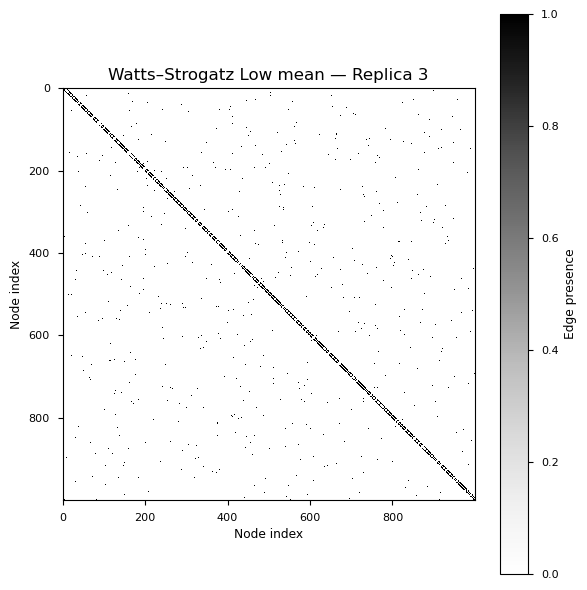

5 0 Watts–Strogatz High mean


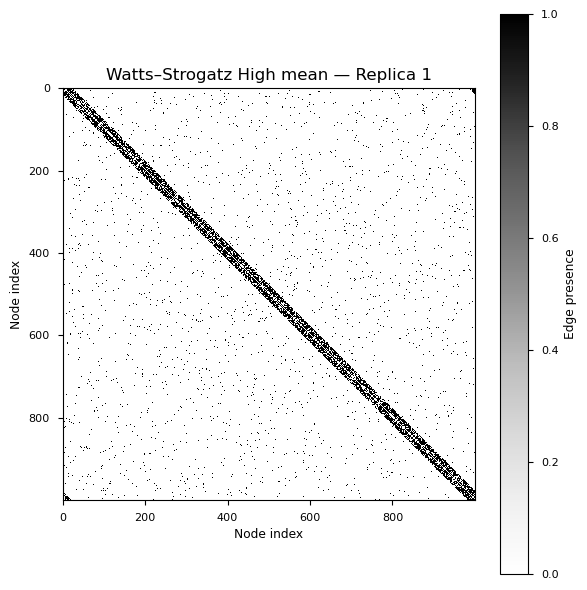

5 1 Watts–Strogatz High mean


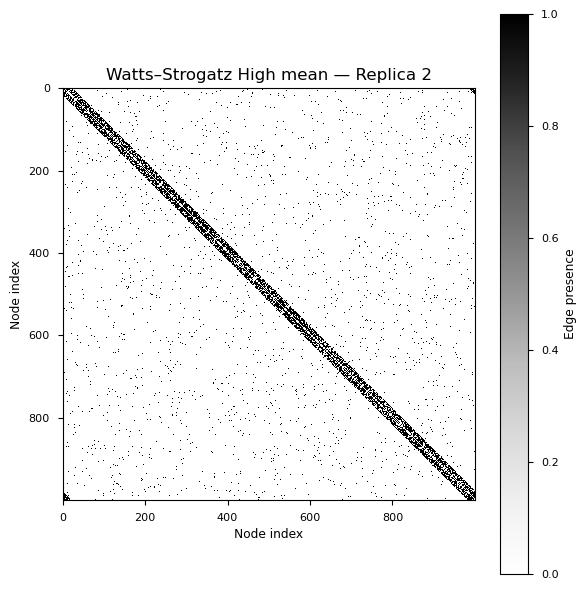

5 2 Watts–Strogatz High mean


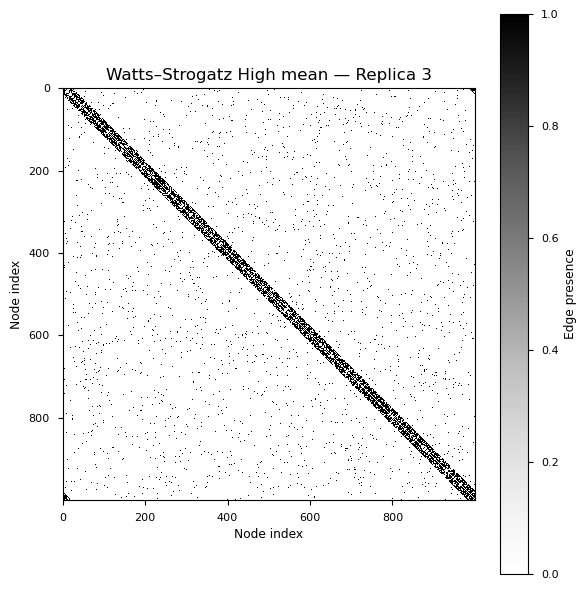

6 0 Erdős–Rényi Low mean


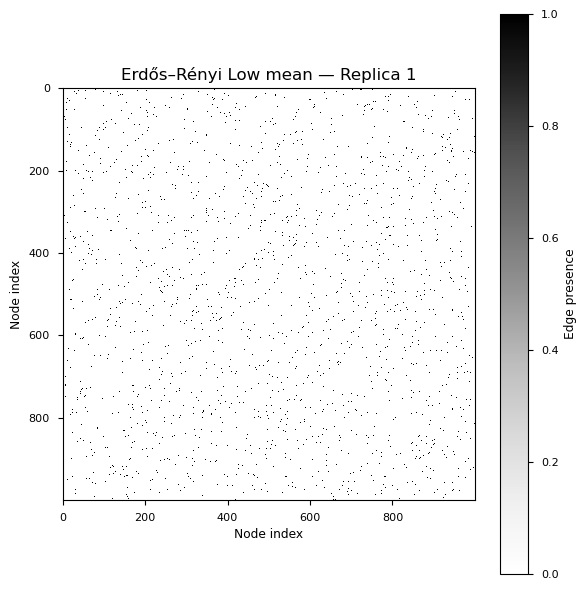

6 1 Erdős–Rényi Low mean


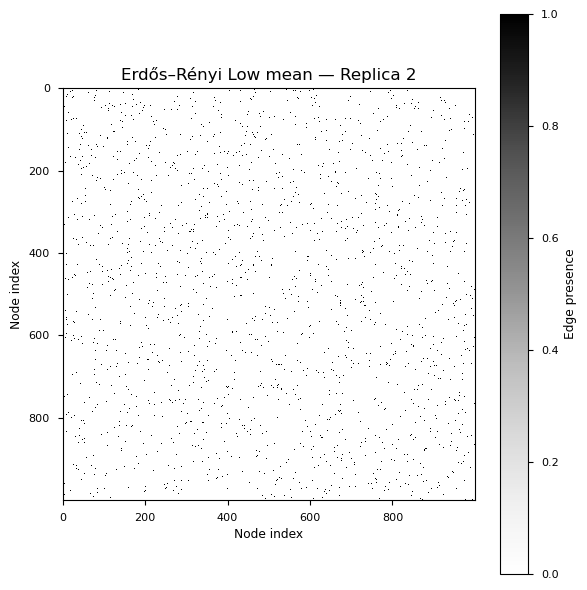

6 2 Erdős–Rényi Low mean


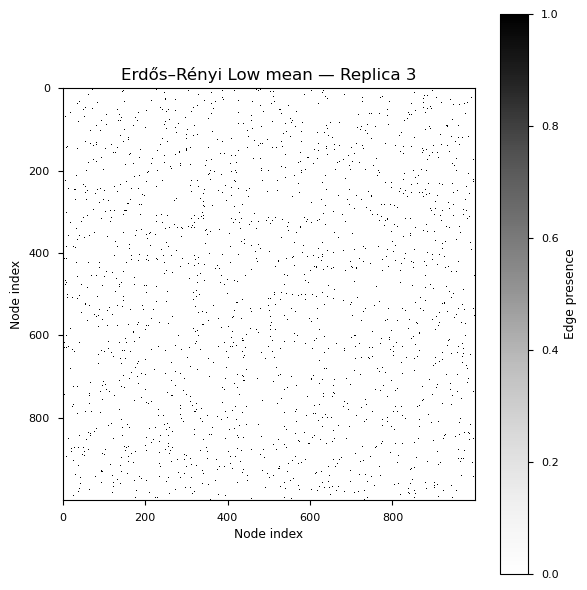

7 0 Erdős–Rényi High mean


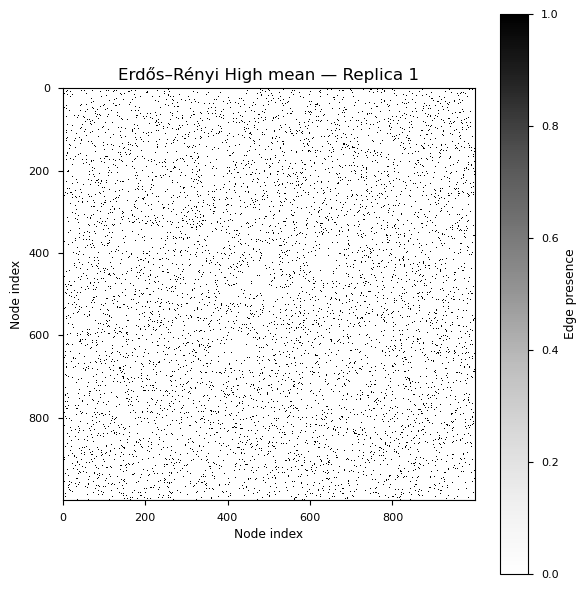

7 1 Erdős–Rényi High mean


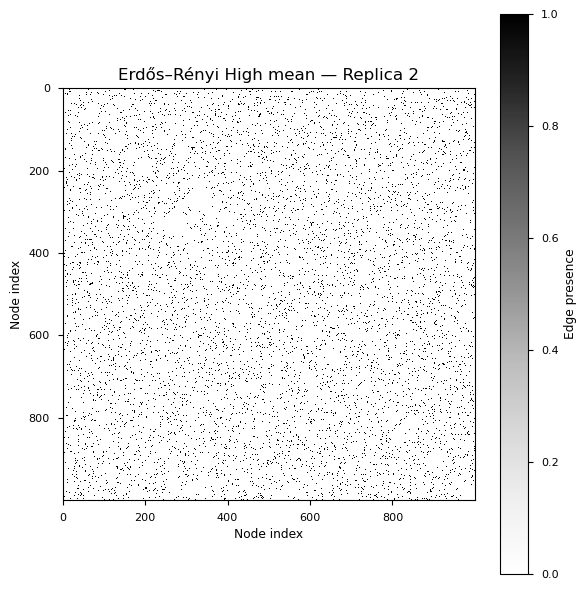

7 2 Erdős–Rényi High mean


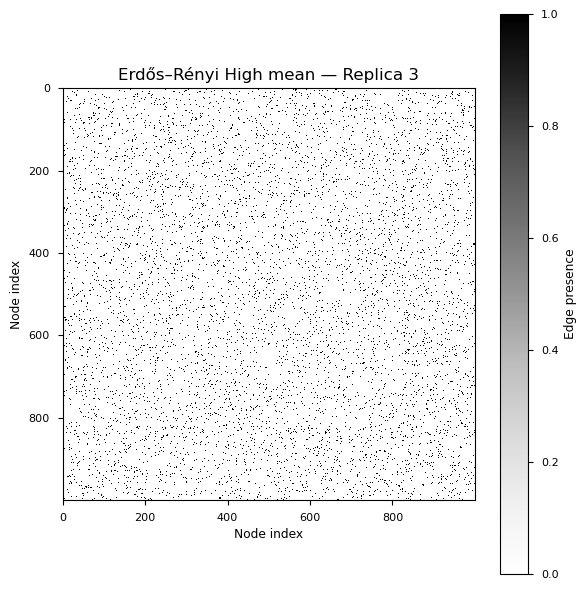

8 0 Fully Connected


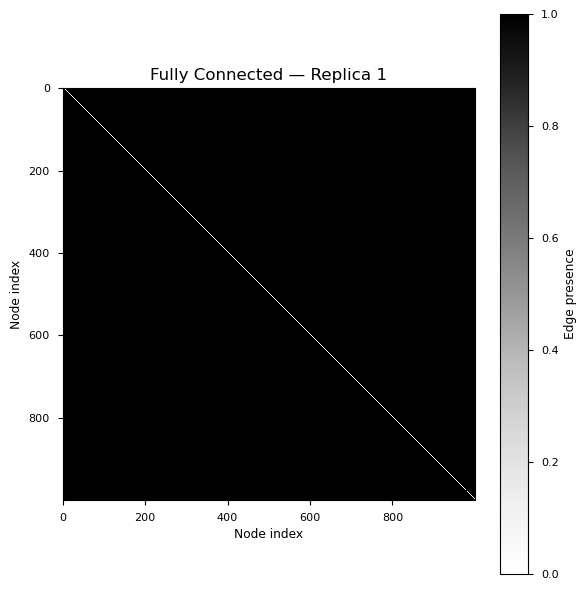

8 1 Fully Connected


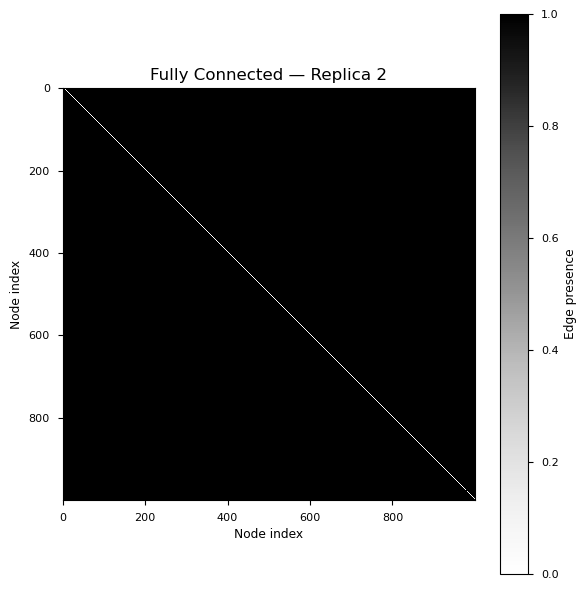

8 2 Fully Connected


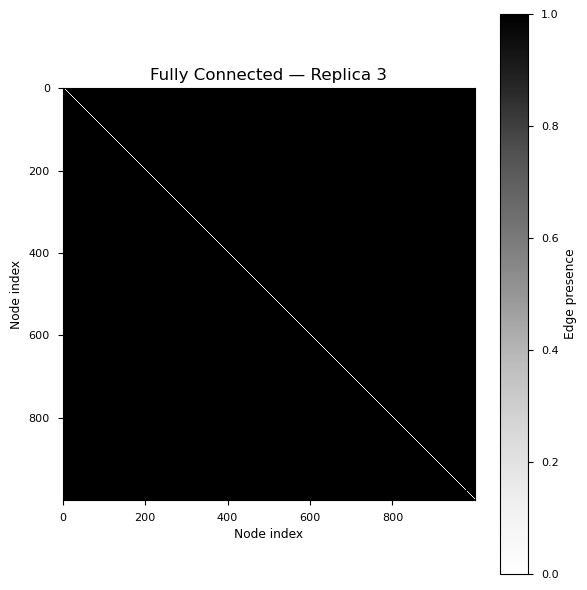

9 0 Barabási–Albert Low mean


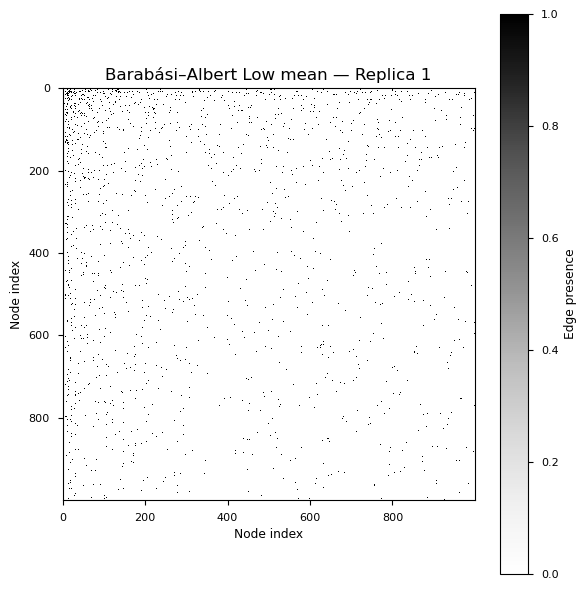

9 1 Barabási–Albert Low mean


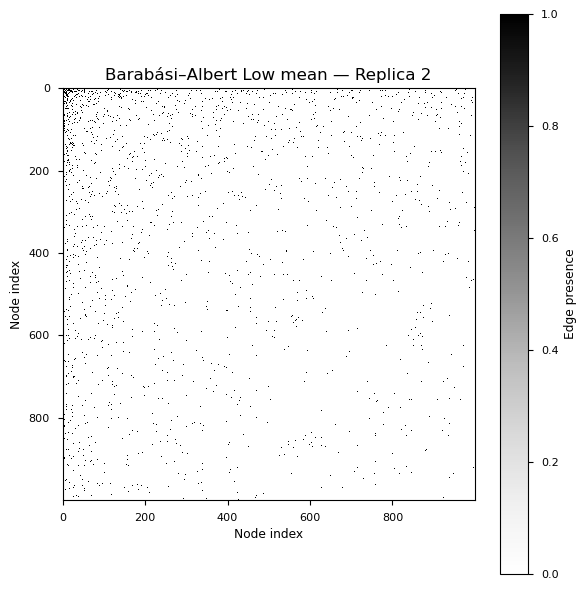

9 2 Barabási–Albert Low mean


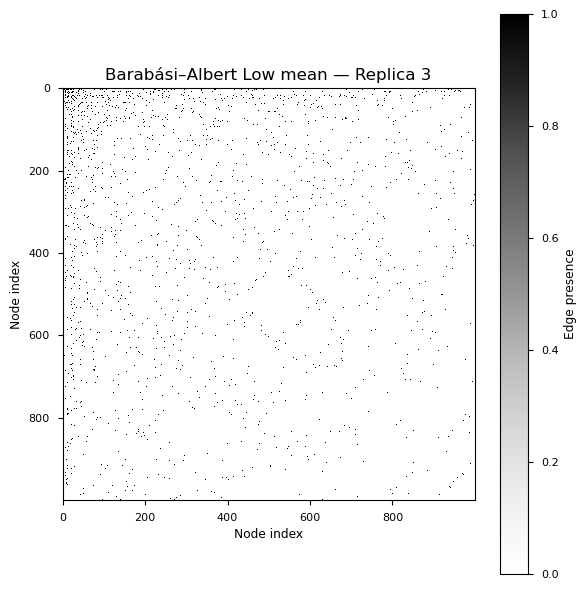

10 0 Barabási–Albert High mean


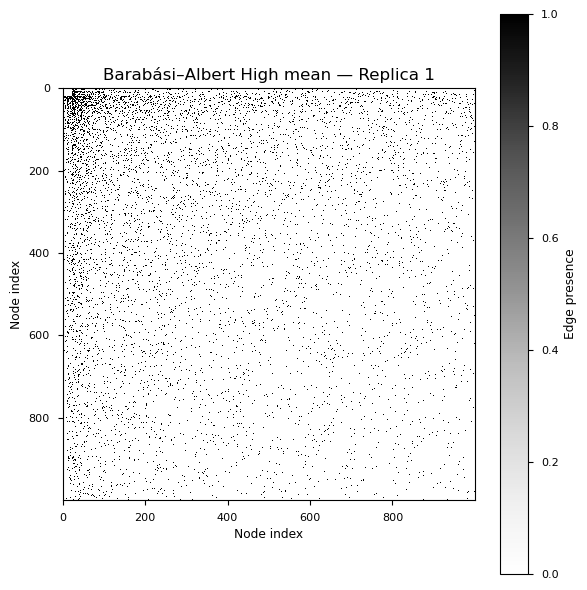

10 1 Barabási–Albert High mean


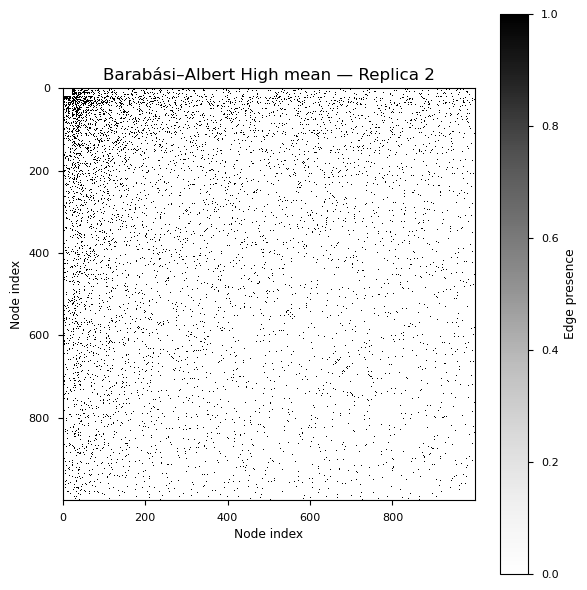

10 2 Barabási–Albert High mean


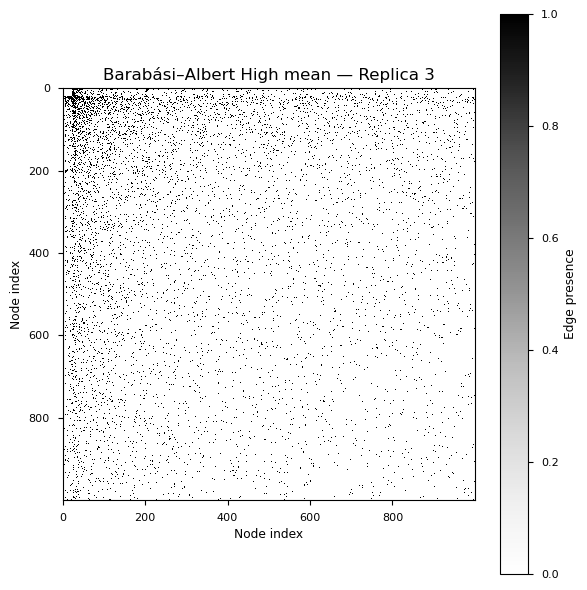

In [98]:
num_networks, num_replicas, N, _ = all_adj.shape

network_names = [
    "LL",
    "LH",
    "HL",
    "HH",
    "Watts–Strogatz Low mean",
    "Watts–Strogatz High mean",
    "Erdős–Rényi Low mean",
    "Erdős–Rényi High mean",
    "Fully Connected",
    "Barabási–Albert Low mean",
    "Barabási–Albert High mean",
]

for i in range(num_networks):
    for r in range(num_replicas):
        print(i, r, network_names[i])
        A = all_adj[i, r]

        plt.figure(figsize=(6, 6))
        plt.imshow(A, cmap="Greys", interpolation="none")
        plt.colorbar(label="Edge presence")
        plt.title(f"{network_names[i]} — Replica {r+1}", fontsize=12)
        plt.xlabel("Node index")
        plt.ylabel("Node index")
        plt.tight_layout()
        plt.show()

TEST BUG: VARYING FREQ SPREAD


In [99]:
print("CUDA:", torch.cuda.is_available())


CUDA: True


In [100]:
all_adj.shape

(11, 3, 1000, 1000)

In [109]:
import numpy as np
import torch

#from utils.kuramotoTorch import KuramotoFast
# plv_matrix_vectorized, dfa_scales, DFA, FA_metric — your imports

k_values = np.linspace(1, 60, 15)
n_nodes = 1000
n_oscillators = 100
sampling_rate = 200
frequency_spread = 3
node_frequencies = [10.0] * n_nodes
use_cuda = torch.cuda.is_available()
time = 10

num_networks, num_replicas, N, _ = all_adj.shape
assert num_networks == 11 and num_replicas == 3

network_names = [
    "LL", "LH", "HL", "HH",
    "Watts–Strogatz Low mean", "Watts–Strogatz High mean",
    "Erdős–Rényi Low mean", "Erdős–Rényi High mean",
    "Fully Connected",
    "Barabási–Albert Low mean", "Barabási–Albert High mean",
]


def run_simulation_batch(i_start, i_end):
    """Networks i_start .. i_end-1, all replicas. Returns dict of (n_batch, 3, n_k) arrays."""
    n_batch = i_end - i_start
    n_k = len(k_values)

    order_matrix = np.zeros((n_batch, num_replicas, n_k))
    variability_matrix = np.zeros((n_batch, num_replicas, n_k))
    plv_matrix = np.zeros((n_batch, num_replicas, n_k))
    dfa_matrix = np.zeros((n_batch, num_replicas, n_k))
    fa_matrix = np.zeros((n_batch, num_replicas, n_k))

    for local_i, i in enumerate(range(i_start, i_end)):
        print(f"Network {i}: {network_names[i]}")
        for r in range(num_replicas):
            print(f"  replica {r + 1}/3")
            W = all_adj[i, r]

            for k_idx, k in enumerate(k_values):
                random_seed = int(np.random.randint(0, 1_000_000))

                model = KuramotoFast(
                    n_nodes=n_nodes,
                    n_oscillators=n_oscillators,
                    k_list=[k] * n_nodes,
                    weight_matrix=W,
                    node_frequencies=node_frequencies,
                    sampling_rate=sampling_rate,
                    frequency_spread=frequency_spread,
                    use_cuda=use_cuda,
                )
                phase_data = model.simulate(time=time, random_seed=random_seed)
                del model
                if use_cuda:
                    torch.cuda.empty_cache()

                phase_data = phase_data[:, 650:]

                order_ts = np.abs(np.mean(phase_data, axis=0))
                order_mean = order_ts.mean()
                order_std = order_ts.std()

                inst_theta = np.angle(phase_data).T
                plv_mat = plv_matrix_vectorized(inst_theta)
                np.fill_diagonal(plv_mat, 0)
                plv_order = plv_mat[np.triu_indices_from(plv_mat, k=1)].mean()

                scales = dfa_scales()
                global_phasor = np.abs(phase_data).mean(axis=0)
                alpha = DFA(global_phasor)
                fa = FA_metric(global_phasor, scales)

                order_matrix[local_i, r, k_idx] = order_mean
                variability_matrix[local_i, r, k_idx] = order_std
                plv_matrix[local_i, r, k_idx] = plv_order
                dfa_matrix[local_i, r, k_idx] = alpha[0]
                fa_matrix[local_i, r, k_idx] = fa[1]

    return {
        "order_matrix": order_matrix,
        "variability_matrix": variability_matrix,
        "plv_matrix": plv_matrix,
        "dfa_matrix": dfa_matrix,
        "fa_matrix": fa_matrix,
        "k_values": k_values,
        "i_start": i_start,
        "i_end": i_end,
        "network_names": np.array(network_names[i_start:i_end], dtype=object),
    }

In [103]:
cell1array = run_simulation_batch(i_start=0, i_end=4)

np.savez("cell1array31May.npz", **cell1array)
print("cell1array.npz saved, shape:", cell1array["order_matrix"].shape)  # (4, 3, 15)

Network 0: LL
  replica 1/3
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.296
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.648
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.587
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.324
Using device: GPU (CUDA/ROCm)


Estimated FA exponent α = 0.519
Using device: GPU (CUDA/ROCm)


KeyboardInterrupt: 

In [110]:
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU allocated: {alloc:.2f} GB")
    print(f"GPU reserved:  {reserved:.2f} GB")
else:
    print("CUDA not available")

GPU allocated: 16.46 GB
GPU reserved:  16.47 GB


In [ ]:
cell2array = run_simulation_batch(i_start=4, i_end=8)

np.savez("cell2array.npz", **cell2array)
print("cell2array.npz saved, shape:", cell2array["order_matrix"].shape)  # (4, 3, 15)

In [105]:
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU allocated: {alloc:.2f} GB")
    print(f"GPU reserved:  {reserved:.2f} GB")
else:
    print("CUDA not available")

GPU allocated: 16.46 GB
GPU reserved:  16.47 GB


In [ ]:
cell3array = run_simulation_batch(i_start=8, i_end=11)

np.savez("cell3array.npz", **cell3array)
print("cell3array.npz saved, shape:", cell3array["order_matrix"].shape)  # (3, 3, 15)

In [106]:
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU allocated: {alloc:.2f} GB")
    print(f"GPU reserved:  {reserved:.2f} GB")
else:
    print("CUDA not available")

GPU allocated: 16.46 GB
GPU reserved:  16.47 GB


In [ ]:
def load_cell(path):
    return dict(np.load(path, allow_pickle=True))

c1 = load_cell("cell1array.npz")
c2 = load_cell("cell2array.npz")
c3 = load_cell("cell3array.npz")

order_matrix = np.concatenate([c1["order_matrix"], c2["order_matrix"], c3["order_matrix"]], axis=0)
variability_matrix = np.concatenate([c1["variability_matrix"], c2["variability_matrix"], c3["variability_matrix"]], axis=0)
plv_matrix = np.concatenate([c1["plv_matrix"], c2["plv_matrix"], c3["plv_matrix"]], axis=0)
dfa_matrix = np.concatenate([c1["dfa_matrix"], c2["dfa_matrix"], c3["dfa_matrix"]], axis=0)
fa_matrix = np.concatenate([c1["fa_matrix"], c2["fa_matrix"], c3["fa_matrix"]], axis=0)
k_values = c1["k_values"]

assert order_matrix.shape == (11, 3, len(k_values))

np.savez(
    "kuramoto_final_results.npz",
    order_matrix=order_matrix,
    variability_matrix=variability_matrix,
    plv_matrix=plv_matrix,
    dfa_matrix=dfa_matrix,
    fa_matrix=fa_matrix,
    k_values=k_values,
    network_names=np.array(network_names, dtype=object),
)
print("Final saved: kuramoto_final_results.npz", order_matrix.shape)

In [107]:
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU allocated: {alloc:.2f} GB")
    print(f"GPU reserved:  {reserved:.2f} GB")
else:
    print("CUDA not available")

GPU allocated: 16.46 GB
GPU reserved:  16.47 GB
